<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🔬 Redes Neuronales Convolucionales en Profundidad</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 4 — Filtros aprendidos, mapas de activación, regularización, aumento de datos y transferencia de aprendizaje</p>
</div>

Este notebook asume que ya se revisaron <code>2-vision-por-computador.ipynb</code> (qué es un kernel y la operación de convolución) e <code>1-fundamentos-redes-neuronales.ipynb</code> (la neurona artificial, las funciones de activación y cómo se entrena un modelo con Keras). Por lo tanto, aquí no se repiten esos fundamentos: se retoman directamente para construir una red neuronal convolucional (CNN) completa y profundizar en los aspectos que la hacen distinta de una red densa simple — qué aprenden realmente sus filtros, cómo se le puede hacer sobreajustar (y cómo evitarlo), y cómo reutilizar redes ya entrenadas por otros en lugar de partir siempre de cero.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#cnn-base">CNN base sobre MNIST</a></li>
<li><a href="#filtros-aprendidos">Visualización de filtros aprendidos</a></li>
<li><a href="#mapas-activacion">Mapas de activación (feature maps)</a></li>
<li><a href="#dropout">Regularización con Dropout</a></li>
<li><a href="#aumento-datos">Aumento de datos (data augmentation)</a></li>
<li><a href="#transferencia">Transferencia de aprendizaje</a></li>
<li><a href="#comparacion-final">Comparación final</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="cnn-base"></a>

## <span style="color:#F97066;">CNN base sobre MNIST</span>

A continuación se construye una CNN sencilla sobre el dataset MNIST, siguiendo la arquitectura clásica: capas <code>Conv2D</code> que extraen características locales mediante la convolución ya vista en <code>2-vision-por-computador.ipynb</code> (solo que aquí los valores del kernel se aprenden, no se fijan a mano), capas <code>MaxPooling2D</code> que reducen la dimensionalidad conservando la información más relevante, y capas <code>Dense</code> finales que realizan la clasificación — exactamente como las vistas en <code>1-fundamentos-redes-neuronales.ipynb</code>.

Este modelo es el punto de partida de todo lo que sigue: en las próximas secciones se abre la "caja negra" de esta misma red para observar qué aprendieron sus filtros, se la fuerza a sobreajustar para luego corregirlo, y se compara con el uso de un modelo ya preentrenado.

Para que el entrenamiento sea rápido en un entorno sin GPU, se utiliza solo un subconjunto pequeño de MNIST (5000 imágenes de entrenamiento, 1000 de prueba) en lugar de las 60&nbsp;000 disponibles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Semillas para que la ejecución sea razonablemente reproducible
np.random.seed(42)
tf.random.set_seed(42)

# 1. Cargar MNIST (ya utilizado en unidades anteriores del curso)
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# 2. Tomar un subconjunto pequeño para que el entrenamiento sea rápido
N_TRAIN = 5000
N_TEST = 1000
X_train = X_train_full[:N_TRAIN]
y_train = y_train_full[:N_TRAIN]
X_test = X_test_full[:N_TEST]
y_test = y_test_full[:N_TEST]

# 3. Normalizar a [0, 1] y agregar el canal (MNIST es escala de grises: 1 solo canal)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (5000, 28, 28, 1), Prueba: (1000, 28, 28, 1)


In [2]:
# 4. Arquitectura: 2 bloques Conv2D + MaxPooling2D, seguidos de capas densas
modelo_base = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(8, (3, 3), activation="relu", name="conv1"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation="relu", name="conv2"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

modelo_base.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# 5. Entrenar sobre el subconjunto pequeño
historial_base = modelo_base.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=0,
)

# 6. Evaluar sobre el conjunto de prueba
loss_base, acc_base = modelo_base.evaluate(X_test, y_test, verbose=0)
print(f"Precisión de validación (CNN base): {acc_base:.3f}")

Precisión de validación (CNN base): 0.910


Con 10 clases, una única cifra de accuracy no dice **cuáles** dígitos confunde el modelo. Como ya se explicó en <code>Unidad 3/6-pipelines-evaluacion.ipynb</code>, la matriz de confusión y las métricas por clase (precision, recall, F1) responden esa pregunta con más detalle — aquí extendidas de un problema binario a uno de 10 clases: la matriz de confusión pasa a ser de 10×10, y cada clase (dígito) tiene su propia precision, recall y F1.

Reporte de clasificación (CNN base, conjunto de prueba):

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        85
           1       0.98      0.98      0.98       126
           2       0.98      0.85      0.91       116
           3       0.88      0.93      0.90       107
           4       0.97      0.87      0.92       110
           5       0.86      0.95      0.90        87
           6       0.93      0.92      0.92        87
           7       0.87      0.88      0.87        99
           8       0.86      0.83      0.85        89
           9       0.82      0.93      0.87        94

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



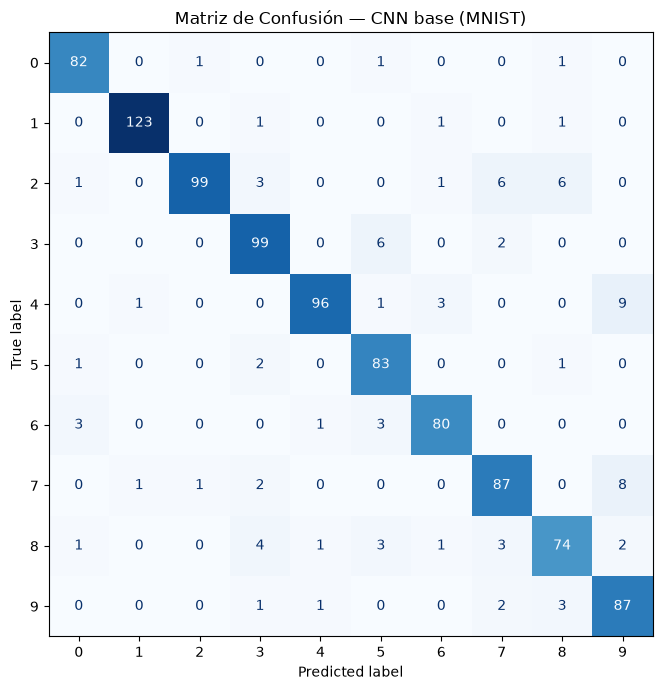

In [4]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Predicciones del modelo base sobre el conjunto de prueba
y_pred_base = np.argmax(modelo_base.predict(X_test, verbose=0), axis=1)

# 2. Reporte de clasificación por dígito (precision, recall, F1)
print("Reporte de clasificación (CNN base, conjunto de prueba):\n")
print(classification_report(y_test, y_pred_base))

# 3. Matriz de confusión de 10x10
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Matriz de Confusión — CNN base (MNIST)")
plt.tight_layout()
plt.show()

La diagonal concentra la gran mayoría de las predicciones, consistente con una accuracy alta, pero los valores fuera de la diagonal muestran exactamente dónde falla el modelo: en MNIST, las confusiones más frecuentes suelen darse entre dígitos que comparten trazos similares (por ejemplo, 4 con 9, o 3 con 5 y 8). Esa información — invisible en una sola cifra de accuracy — es la que permitiría decidir, en un caso real, si conviene recolectar más ejemplos de un dígito en particular o ajustar el modelo para ese caso específico.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota — ¿y el mAP@50, el índice de Jaccard o el coeficiente de Dice?</strong><br>
Es común escuchar sobre <strong>mAP</strong> (<em>mean Average Precision</em>, a veces indicada como "mAP@50") como métrica para modelos de visión por computador. No aplica aquí porque resuelve un problema distinto: mientras que este notebook hace <strong>clasificación</strong> (¿qué dígito es esta imagen completa?), mAP evalúa <strong>detección de objetos</strong> (¿dónde está cada objeto dentro de la imagen, y qué es?), donde el modelo predice cuadros delimitadores (<em>bounding boxes</em>) además de una clase.<br><br>
Para eso hace falta primero el <strong>IoU</strong> (<em>Intersection over Union</em>): el área de superposición entre el cuadro predicho y el real, dividida entre el área de su unión. "mAP@50" indica que una predicción solo cuenta como acierto si su IoU supera 0.5. Con ese criterio de acierto, se calcula precision y recall por clase — igual que en la matriz de confusión de arriba — y el área bajo esa curva (Average Precision) se promedia entre todas las clases para obtener el mAP. Es, en el fondo, la misma familia de ideas (precision, recall, un umbral de decisión) aplicada a una tarea con una capa adicional de complejidad geométrica, y queda fuera del alcance de este curso, centrado en clasificación.

El IoU es, de hecho, exactamente el mismo cálculo que en estadística se conoce como <strong>índice de Jaccard</strong>: una medida general de similitud entre dos conjuntos, $J(A,B) = |A \cap B| / |A \cup B|$. "IoU" es simplemente el nombre que recibe esa misma fórmula cuando $A$ y $B$ son las áreas de dos cuadros delimitadores (o, como se ve abajo, dos máscaras de píxeles).
</div>

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota — segmentación y el coeficiente de Dice</strong><br>
Existe una tercera tarea de visión, distinta tanto de la clasificación (una etiqueta por imagen) como de la detección (una etiqueta y un cuadro por objeto): la <strong>segmentación</strong>, que asigna una clase a <em>cada píxel</em> de la imagen (por ejemplo, delinear exactamente el contorno de un tumor en una imagen médica). Ahí, en lugar de comparar cuadros delimitadores, se comparan dos máscaras de píxeles — la predicha y la real — y el índice de Jaccard (IoU) sigue siendo una opción válida para medir su superposición.<br><br>
En segmentación, sin embargo, es más común reportar el <strong>coeficiente de Dice</strong>: $\text{Dice}(A,B) = 2|A \cap B| / (|A| + |B|)$. Es una fórmula parecida al índice de Jaccard, pero no idéntica — pondera el área de superposición al doble, lo que hace a Dice ligeramente menos sensible que Jaccard a errores pequeños. De hecho, el coeficiente de Dice es <strong>matemáticamente idéntico al F1-score</strong> ya visto en <code>Unidad 3/6-pipelines-evaluacion.ipynb</code>: si se trata cada píxel como una predicción binaria (¿pertenece a la región de interés o no?), $|A \cap B|$ son los verdaderos positivos, y la fórmula de Dice se reduce exactamente a $2TP / (2TP + FP + FN)$, la definición de F1. Es la misma idea de siempre, aplicada píxel por píxel en lugar de imagen por imagen — y, al igual que la detección de objetos, la segmentación queda fuera del alcance de este curso.
</div>

<a id="filtros-aprendidos"></a>

## <span style="color:#F97066;">Visualización de filtros aprendidos</span>

Cada filtro de una capa <code>Conv2D</code> es, literalmente, el mismo tipo de kernel visto en <code>2-vision-por-computador.ipynb</code> (por ejemplo, el laplaciano o los de Sobel), con la diferencia de que sus valores no se definen a mano: se ajustan mediante descenso de gradiente durante el entrenamiento, igual que cualquier otro peso de la red. A continuación se extraen los pesos ya entrenados de la primera capa convolucional (<code>conv1</code>) y se grafican como pequeñas imágenes, para observar qué patrones aprendió a detectar la red por sí sola.

Forma de los filtros: (3, 3, 1, 8)


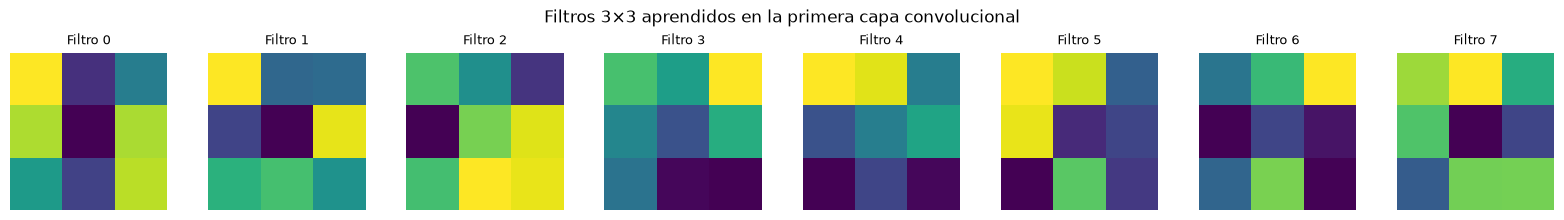

In [5]:
# 1. Extraer los pesos de la primera capa convolucional
capa_conv1 = modelo_base.get_layer("conv1")
filtros, sesgos = capa_conv1.get_weights()
print(f"Forma de los filtros: {filtros.shape}")  # (alto, ancho, canales_entrada, num_filtros)

# 2. Graficar cada filtro (normalizado a [0, 1] únicamente para visualizarlo)
num_filtros = filtros.shape[-1]
fig, axes = plt.subplots(1, num_filtros, figsize=(2 * num_filtros, 2.2))
for i, ax in enumerate(axes):
    f = filtros[:, :, 0, i]
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f_norm, cmap="viridis")
    ax.set_title(f"Filtro {i}", fontsize=9)
    ax.axis("off")
plt.suptitle("Filtros 3×3 aprendidos en la primera capa convolucional")
plt.tight_layout()
plt.show()

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Al ser la primera capa de la red, estos filtros operan directamente sobre la imagen de entrada, por lo que suelen especializarse en patrones muy simples y locales: bordes en distintas orientaciones, manchas claras u oscuras, y gradientes de intensidad — de forma parecida a los kernels de Sobel vistos anteriormente, solo que estos ocho se descubrieron automáticamente. En capas convolucionales más profundas (no incluidas aquí para mantener el modelo pequeño), estos patrones simples se combinan entre sí para formar detectores de trazos, curvas y, finalmente, formas completas de dígitos.
</div>

<a id="mapas-activacion"></a>

## <span style="color:#F97066;">Mapas de activación (feature maps)</span>

Un filtro aprendido, por sí solo, es difícil de interpretar. Resulta más claro observar su efecto: qué produce ese filtro al aplicarse sobre una imagen real. A ese resultado — la salida de un filtro convolucional sobre una imagen específica — se le llama **mapa de activación** o *feature map*. Las zonas con valores altos (colores más claros en la visualización) indican dónde ese filtro "se activa" con más fuerza, es decir, dónde encontró el patrón que aprendió a detectar.

In [6]:
# 1. Construir un modelo auxiliar que expone la salida de la primera capa convolucional
modelo_activaciones = models.Model(
    inputs=modelo_base.inputs,
    outputs=modelo_base.get_layer("conv1").output,
)

# 2. Elegir una imagen de ejemplo del conjunto de prueba
idx_ejemplo = 7
imagen_ejemplo = X_test[idx_ejemplo:idx_ejemplo + 1]
print(f"Dígito real de la imagen de ejemplo: {y_test[idx_ejemplo]}")

# 3. Calcular los mapas de activación para esa imagen
activaciones = modelo_activaciones.predict(imagen_ejemplo, verbose=0)
print(f"Forma de las activaciones: {activaciones.shape}")  # (1, alto, ancho, num_filtros)

Dígito real de la imagen de ejemplo: 9


Forma de las activaciones: (1, 26, 26, 8)


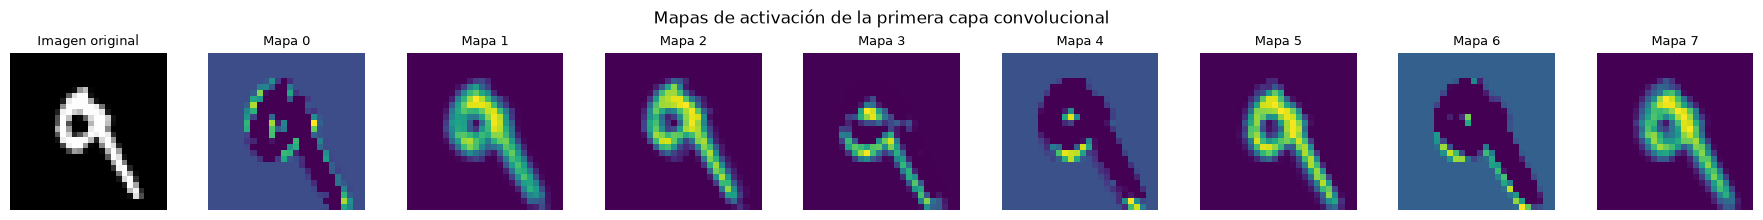

In [7]:
# 4. Graficar la imagen original junto con cada mapa de activación
num_filtros = activaciones.shape[-1]
fig, axes = plt.subplots(1, num_filtros + 1, figsize=(2 * (num_filtros + 1), 2.2))
axes[0].imshow(imagen_ejemplo[0, :, :, 0], cmap="gray")
axes[0].set_title("Imagen original", fontsize=9)
axes[0].axis("off")
for i in range(num_filtros):
    axes[i + 1].imshow(activaciones[0, :, :, i], cmap="viridis")
    axes[i + 1].set_title(f"Mapa {i}", fontsize=9)
    axes[i + 1].axis("off")
plt.suptitle("Mapas de activación de la primera capa convolucional")
plt.tight_layout()
plt.show()

<a id="dropout"></a>

## <span style="color:#F97066;">Regularización con Dropout</span>

Con pocos datos de entrenamiento y suficientes épocas, una red puede memorizar los ejemplos de entrenamiento en lugar de aprender patrones generales — esto es el **sobreajuste** (*overfitting*): la precisión de entrenamiento sigue subiendo mientras la de validación se estanca o incluso empeora. Para hacer visible este fenómeno, a continuación se entrena el mismo modelo dos veces sobre el mismo subconjunto pequeño de datos, durante muchas más épocas de las necesarias: una vez sin regularización y otra con **Dropout**.

<code>Dropout(0.5)</code> desactiva aleatoriamente, en cada paso de entrenamiento, el 50&nbsp;% de las neuronas de la capa a la que se aplica. Esto impide que la red dependa demasiado de neuronas específicas y la obliga a distribuir lo aprendido de forma más redundante — en la práctica, actúa como una regularización que reduce el sobreajuste. Durante la evaluación (o predicción), Dropout se desactiva automáticamente y todas las neuronas participan.

In [8]:
def construir_modelo_conv(dropout_rate=0.0):
    """Misma arquitectura base, con una capa Dense más grande (para facilitar el sobreajuste)
    y un Dropout opcional antes de la capa de salida."""
    capas = [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
    ]
    if dropout_rate > 0:
        capas.append(layers.Dropout(dropout_rate))
    capas.append(layers.Dense(10, activation="softmax"))
    modelo = models.Sequential(capas)
    modelo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo


EPOCAS_OVERFITTING = 25

# 1. Modelo sin Dropout
modelo_sin_dropout = construir_modelo_conv(dropout_rate=0.0)
historial_sin_dropout = modelo_sin_dropout.fit(
    X_train, y_train,
    epochs=EPOCAS_OVERFITTING,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=0,
)

# 2. Modelo con Dropout
modelo_con_dropout = construir_modelo_conv(dropout_rate=0.5)
historial_con_dropout = modelo_con_dropout.fit(
    X_train, y_train,
    epochs=EPOCAS_OVERFITTING,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=0,
)

acc_dropout = historial_con_dropout.history["val_accuracy"][-1]
acc_sin_dropout = historial_sin_dropout.history["val_accuracy"][-1]
print(f"Precisión de validación final (sin Dropout): {acc_sin_dropout:.3f}")
print(f"Precisión de validación final (con Dropout): {acc_dropout:.3f}")

Precisión de validación final (sin Dropout): 0.967
Precisión de validación final (con Dropout): 0.976


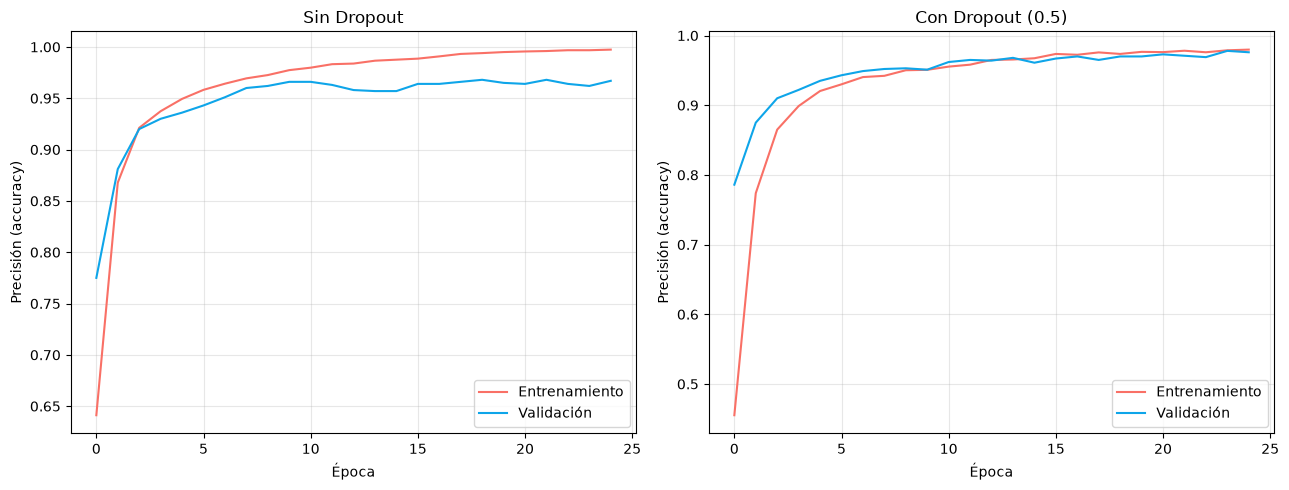

In [9]:
# 3. Comparar las curvas de entrenamiento y validación de ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(historial_sin_dropout.history["accuracy"], color="#F97066", label="Entrenamiento")
axes[0].plot(historial_sin_dropout.history["val_accuracy"], color="#0EA5E9", label="Validación")
axes[0].set_title("Sin Dropout")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Precisión (accuracy)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(historial_con_dropout.history["accuracy"], color="#F97066", label="Entrenamiento")
axes[1].plot(historial_con_dropout.history["val_accuracy"], color="#0EA5E9", label="Validación")
axes[1].set_title("Con Dropout (0.5)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Precisión (accuracy)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
En el gráfico "Sin Dropout" se espera observar una brecha creciente entre la curva de entrenamiento (que sigue subiendo) y la de validación (que se estanca): esa brecha es la señal característica del sobreajuste. En el gráfico "Con Dropout", ambas curvas deberían quedar más cercanas entre sí, incluso si la precisión de entrenamiento es algo menor — lo relevante no es maximizar la precisión de entrenamiento, sino que la red generalice mejor a datos que no ha visto.
</div>

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

¿Qué se observaría si <code>dropout_rate</code> se aumentara a 0.8, o se redujera a 0.2? ¿Y si la capa <code>Dropout</code> se agregara también después de las capas convolucionales (por ejemplo, con una tasa menor, como 0.25)?

<a id="aumento-datos"></a>

## <span style="color:#F97066;">Aumento de datos (data augmentation)</span>

Otra manera de combatir el sobreajuste que se observó en la sección anterior es, en lugar de restringir el modelo, ampliar artificialmente la variedad de los datos de entrenamiento: aplicar pequeñas transformaciones aleatorias (rotaciones, zoom, desplazamientos) sobre las imágenes originales, de modo que la red vea, en cada época, versiones ligeramente distintas de un mismo dígito y no pueda memorizar tan fácilmente los ejemplos exactos.

En Keras, esto se implementa con capas de preprocesamiento (<code>RandomRotation</code>, <code>RandomZoom</code>, <code>RandomTranslation</code>) que se agregan como parte del propio modelo. Estas capas solo aplican la transformación durante el entrenamiento; durante la evaluación o la predicción se desactivan automáticamente y la imagen pasa sin alterar.

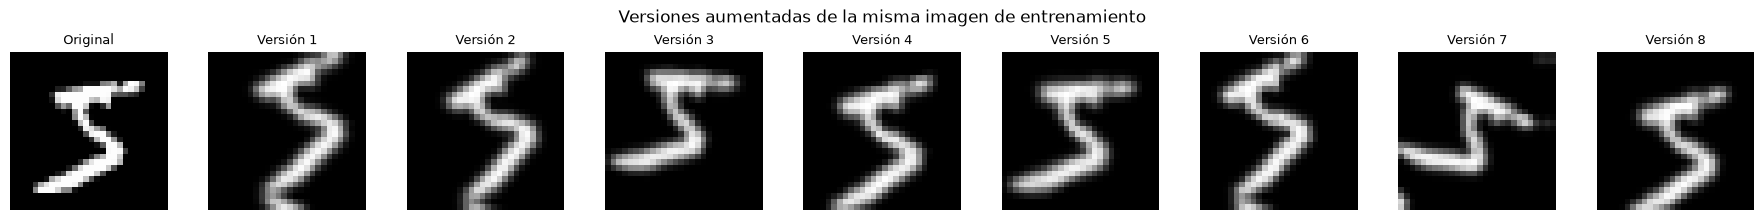

In [10]:
# 1. Definir el pipeline de aumento de datos
data_augmentation = models.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="aumento_datos")

# 2. Tomar una imagen de ejemplo y generar varias versiones aumentadas
imagen_original = X_train[0:1]
num_versiones = 8

fig, axes = plt.subplots(1, num_versiones + 1, figsize=(2 * (num_versiones + 1), 2.2))
axes[0].imshow(imagen_original[0, :, :, 0], cmap="gray")
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")
for i in range(num_versiones):
    imagen_aumentada = data_augmentation(imagen_original, training=True)
    axes[i + 1].imshow(imagen_aumentada[0, :, :, 0], cmap="gray")
    axes[i + 1].set_title(f"Versión {i + 1}", fontsize=9)
    axes[i + 1].axis("off")
plt.suptitle("Versiones aumentadas de la misma imagen de entrenamiento")
plt.tight_layout()
plt.show()

In [11]:
EPOCAS_AUMENTO = 15

# 3. Modelo de referencia, sin aumento de datos, entrenado el mismo número de épocas
modelo_sin_aumento = construir_modelo_conv(dropout_rate=0.0)
historial_sin_aumento = modelo_sin_aumento.fit(
    X_train, y_train,
    epochs=EPOCAS_AUMENTO,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=0,
)

# 4. Modelo con la capa de aumento de datos como primera capa de la red
modelo_con_aumento = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    layers.Conv2D(8, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
modelo_con_aumento.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
historial_con_aumento = modelo_con_aumento.fit(
    X_train, y_train,
    epochs=EPOCAS_AUMENTO,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=0,
)

acc_sin_aumento = historial_sin_aumento.history["val_accuracy"][-1]
acc_con_aumento = historial_con_aumento.history["val_accuracy"][-1]
print(f"Precisión de validación sin aumento de datos: {acc_sin_aumento:.3f}")
print(f"Precisión de validación con aumento de datos: {acc_con_aumento:.3f}")

Precisión de validación sin aumento de datos: 0.957
Precisión de validación con aumento de datos: 0.937


<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Con un subconjunto tan pequeño de datos (5000 imágenes) y transformaciones suaves, la mejora del aumento de datos frente al modelo de referencia puede ser modesta en pocas épocas; su beneficio se hace más notorio cuantos menos datos propios se tengan y cuantas más épocas de entrenamiento se realicen, ya que retrasa el punto en el que la red empieza a memorizar los ejemplos.
</div>

<a id="transferencia"></a>

## <span style="color:#F97066;">Transferencia de aprendizaje</span>

Hasta ahora, cada red se entrenó completamente desde cero. La **transferencia de aprendizaje** propone lo contrario: partir de una red ya entrenada por alguien más, sobre un dataset mucho más grande, y reutilizar lo que esa red ya aprendió a detectar (bordes, texturas, formas) como punto de partida para un problema nuevo — en lugar de que cada modelo tenga que redescubrir esos mismos patrones básicos desde cero.

A continuación se utiliza **MobileNetV2**, una red convolucional pequeña preentrenada sobre ImageNet (1.4 millones de imágenes, 1000 categorías), disponible directamente en <code>tf.keras.applications</code>. Se descartan sus capas de clasificación originales (<code>include_top=False</code>), se **congelan** todos sus pesos convolucionales (<code>trainable = False</code>) para que actúen solo como un extractor de características, y se entrena únicamente un clasificador nuevo y pequeño encima, sobre un subconjunto muy reducido de CIFAR-10 con solo 3 de sus 10 clases.

In [12]:
# 1. Cargar CIFAR-10 y quedarse solo con 3 clases, para un problema pequeño
(X_cifar_train, y_cifar_train), (X_cifar_test, y_cifar_test) = tf.keras.datasets.cifar10.load_data()
y_cifar_train = y_cifar_train.flatten()
y_cifar_test = y_cifar_test.flatten()

CLASES_SELECCIONADAS = [0, 1, 8]  # avión, automóvil, barco (índices originales de CIFAR-10)
NOMBRES_CLASES = {0: "avión", 1: "automóvil", 8: "barco"}

IMAGENES_POR_CLASE_TRAIN = 100
IMAGENES_POR_CLASE_TEST = 30


def tomar_subconjunto(X, y, clases, n_por_clase):
    X_sub, y_sub = [], []
    for clase in clases:
        idx_clase = np.where(y == clase)[0][:n_por_clase]
        X_sub.append(X[idx_clase])
        y_sub.append(np.full(len(idx_clase), clase))
    return np.concatenate(X_sub), np.concatenate(y_sub)


X_tl_train, y_tl_train = tomar_subconjunto(
    X_cifar_train, y_cifar_train, CLASES_SELECCIONADAS, IMAGENES_POR_CLASE_TRAIN
)
X_tl_test, y_tl_test = tomar_subconjunto(
    X_cifar_test, y_cifar_test, CLASES_SELECCIONADAS, IMAGENES_POR_CLASE_TEST
)

# 2. Reetiquetar las clases originales (0, 1, 8) como (0, 1, 2) para la capa de salida
mapa_etiquetas = {clase: i for i, clase in enumerate(CLASES_SELECCIONADAS)}
y_tl_train = np.array([mapa_etiquetas[c] for c in y_tl_train])
y_tl_test = np.array([mapa_etiquetas[c] for c in y_tl_test])

print(f"Entrenamiento: {X_tl_train.shape}, Prueba: {X_tl_test.shape}")

Entrenamiento: (300, 32, 32, 3), Prueba: (90, 32, 32, 3)


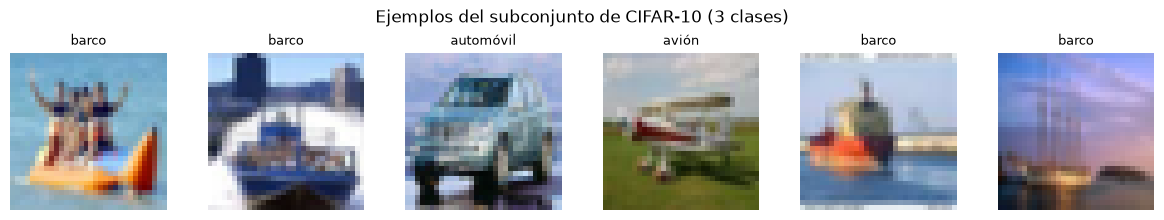

In [13]:
# 3. Vista previa de algunas imágenes del subconjunto
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for ax, idx in zip(axes, np.random.choice(len(X_tl_train), 6, replace=False)):
    ax.imshow(X_tl_train[idx])
    ax.set_title(NOMBRES_CLASES[CLASES_SELECCIONADAS[y_tl_train[idx]]], fontsize=9)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de CIFAR-10 (3 clases)")
plt.tight_layout()
plt.show()

In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

TAMANO_ENTRADA = 96


def preparar_para_mobilenet(X):
    X = tf.image.resize(X.astype("float32"), (TAMANO_ENTRADA, TAMANO_ENTRADA))
    return preprocess_input(X)


X_tl_train_prep = preparar_para_mobilenet(X_tl_train)
X_tl_test_prep = preparar_para_mobilenet(X_tl_test)

# 1. Cargar MobileNetV2 preentrenada en ImageNet, sin su cabeza de clasificación original
base_preentrenada = MobileNetV2(
    input_shape=(TAMANO_ENTRADA, TAMANO_ENTRADA, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg",
)
# 2. Congelar todos sus pesos: no se actualizan durante el entrenamiento
base_preentrenada.trainable = False
print(f"Capas de la base preentrenada: {len(base_preentrenada.layers)} (todas congeladas)")

Capas de la base preentrenada: 155 (todas congeladas)


Como la base preentrenada queda congelada, sus salidas para una misma imagen nunca cambian durante el entrenamiento. En lugar de recalcularlas en cada época (lo cual sería innecesariamente lento), se calculan una única vez — estas salidas se conocen como características *bottleneck* — y el clasificador nuevo se entrena directamente sobre ellas. El resultado es matemáticamente equivalente a apilar el clasificador sobre la base congelada, pero mucho más rápido.

In [15]:
# 3. Extraer las características (bottleneck) una sola vez, ya que la base está congelada
features_train = base_preentrenada.predict(X_tl_train_prep, verbose=0)
features_test = base_preentrenada.predict(X_tl_test_prep, verbose=0)
print(f"Forma de las características extraídas: {features_train.shape}")

# 4. Clasificador nuevo y pequeño, entrenado únicamente sobre esas características
clasificador_transferencia = models.Sequential([
    layers.Input(shape=features_train.shape[1:]),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(CLASES_SELECCIONADAS), activation="softmax"),
])
clasificador_transferencia.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

historial_transferencia = clasificador_transferencia.fit(
    features_train, y_tl_train,
    epochs=15,
    batch_size=16,
    validation_data=(features_test, y_tl_test),
    verbose=0,
)

loss_tl, acc_tl = clasificador_transferencia.evaluate(features_test, y_tl_test, verbose=0)
print(f"Precisión de validación (transferencia de aprendizaje, 3 clases de CIFAR-10): {acc_tl:.3f}")

Forma de las características extraídas: (300, 1280)


Precisión de validación (transferencia de aprendizaje, 3 clases de CIFAR-10): 0.889


<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Nótese la diferencia de escala: el clasificador nuevo se entrenó con apenas 300 imágenes propias, muchas menos que las 5000 usadas en las secciones anteriores, y aun así puede alcanzar una precisión razonable — porque la mayor parte del trabajo de "aprender a ver" (bordes, texturas, formas) ya venía resuelta por MobileNetV2 gracias a las 1.4 millones de imágenes de ImageNet. En la práctica, cuando se dispone de pocos datos propios, partir de un modelo preentrenado y solo ajustar un clasificador encima casi siempre da mejores resultados que entrenar una red convolucional completa desde cero.
</div>

<a id="comparacion-final"></a>

## <span style="color:#F97066;">Comparación final</span>

Las tres variantes de la CNN entrenadas sobre el mismo subconjunto de MNIST — base, con Dropout y con aumento de datos — se resumen a continuación con su precisión de validación real, obtenida directamente de las celdas anteriores.

In [16]:
from IPython.display import display, HTML

filas = [
    ("CNN base (5 épocas, sin regularización)", acc_base),
    (f"CNN con Dropout (0.5, {EPOCAS_OVERFITTING} épocas)", acc_dropout),
    (f"CNN con aumento de datos ({EPOCAS_AUMENTO} épocas)", acc_con_aumento),
]

filas_html = ""
for i, (nombre, acc) in enumerate(filas):
    estilo_fila = ' style="background:rgba(14,165,233,0.07);"' if i % 2 == 0 else ""
    filas_html += (
        f'<tr{estilo_fila}><td style="padding:6px 14px;">{nombre}</td>'
        f'<td style="padding:6px 14px;">{acc:.1%}</td></tr>'
    )

tabla_html = f"""
<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Modelo</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Precisión de validación</th>
</tr>
</thead>
<tbody>
{filas_html}
</tbody>
</table>
</div>
"""
display(HTML(tabla_html))

Modelo,Precisión de validación
"CNN base (5 épocas, sin regularización)",91.0%
"CNN con Dropout (0.5, 25 épocas)",97.6%
CNN con aumento de datos (15 épocas),93.7%


<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Estos tres modelos no son directamente comparables entre sí en cuanto a "cuál es mejor": se entrenaron con distinto número de épocas y con distintas técnicas, precisamente para exhibir el efecto de cada técnica por separado (Dropout y aumento de datos se evaluaron con más épocas, ya que su efecto en la brecha entre entrenamiento y validación solo se hace evidente cuando hay margen para sobreajustar). La comparación relevante no es la columna de la derecha en aislado, sino frente a la brecha entre precisión de entrenamiento y de validación de cada modelo, discutida en las secciones anteriores.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
Este notebook profundizó en las redes neuronales convolucionales más allá de sus fundamentos:

- Construcción y entrenamiento de una CNN completa (Conv2D + MaxPooling2D + Dense) sobre MNIST.
- Visualización de los filtros aprendidos por la primera capa convolucional, para observar qué patrones detecta cada uno.
- Mapas de activación (*feature maps*): qué partes de una imagen concreta "encienden" cada filtro.
- Regularización con Dropout: cómo se hace visible el sobreajuste y cómo Dropout reduce la brecha entre precisión de entrenamiento y de validación.
- Aumento de datos con capas de Keras (<code>RandomRotation</code>, <code>RandomZoom</code>, <code>RandomTranslation</code>) como estrategia adicional contra el sobreajuste.
- Transferencia de aprendizaje con MobileNetV2 preentrenada en ImageNet, congelando su base y entrenando solo un clasificador nuevo sobre pocos datos propios.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>4-modelos-secuenciales.ipynb</code> — mientras que una CNN es apropiada para datos con estructura espacial (imágenes), las redes recurrentes (RNN) y LSTM están diseñadas para datos con estructura secuencial (series de tiempo, texto), donde el orden entre observaciones importa tanto como su valor.</li>
</ul>
</div>